In [161]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV

import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, f1_score

from sklearn.model_selection import cross_val_predict
import streamlit as st


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
) 
%matplotlib inline

In [2]:
df = pd.read_csv("default of credit card clients.csv")

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
data = df.copy()

In [5]:
data.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm'],
      dtype='str')

In [6]:
data.tail()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1
29999,30000,50000,1,2,1,46,0,0,0,0,...,36535,32428,15313,2078,1800,1430,1000,1000,1000,1


In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_1      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [8]:
data.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [9]:
data.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dpnm         0
dtype: int64

In [10]:
data.dtypes

ID           int64
LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_1        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
dpnm         int64
dtype: object

In [11]:
missing_percentage = (data.isnull().sum() / len(data)) * 100

missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
data[data.duplicated()].head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm


In [14]:
categorical_check_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_1",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for col in categorical_check_cols:
    print(f"\n{col}")
    print(data[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

PAY_1
PAY_1
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    169

In [15]:
data = data.drop(columns=["ID"], errors="ignore")


In [16]:
target = "dpnm"

In [17]:
data[target].value_counts()

dpnm
0    23364
1     6636
Name: count, dtype: int64

In [18]:
data[target].value_counts(normalize=True) * 100

dpnm
0    77.88
1    22.12
Name: proportion, dtype: float64

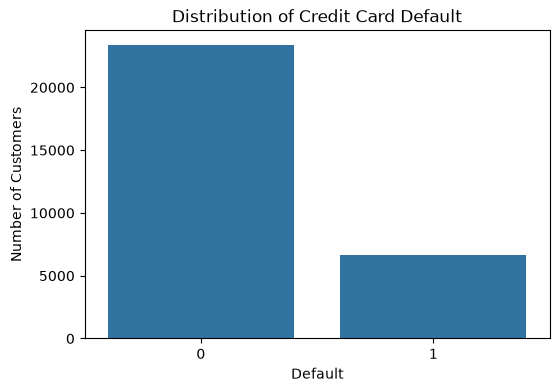

In [19]:
plt.figure(figsize=(6, 4))

sns.countplot(data=data, x=target)

plt.title("Distribution of Credit Card Default")
plt.xlabel("Default")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [21]:
data.shape

(30000, 24)

In [22]:
numerical_cols = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

In [23]:
data[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0


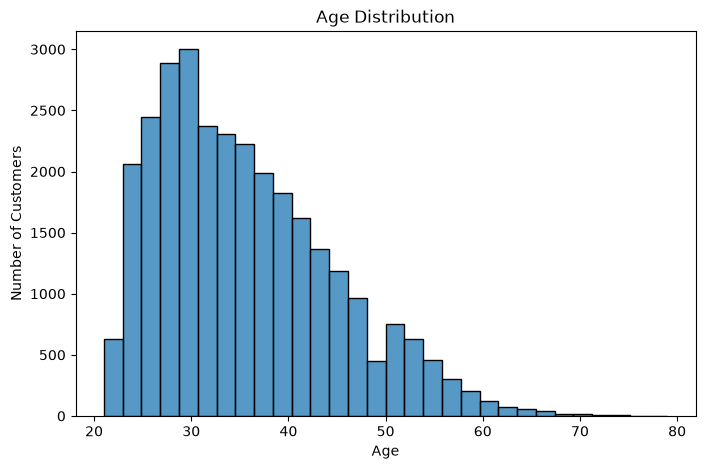

In [24]:
# EDA
plt.figure(figsize=(8, 5))

sns.histplot(data=data, x="AGE", bins=30)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
data["AGE"].describe()

count    30000.000000
mean        35.485500
std          9.217904
min         21.000000
25%         28.000000
50%         34.000000
75%         41.000000
max         79.000000
Name: AGE, dtype: float64

In [26]:
data.groupby("dpnm")["AGE"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
dpnm,,,,,
0,23364,35.417266,34.0,21,79
1,6636,35.725738,34.0,21,75


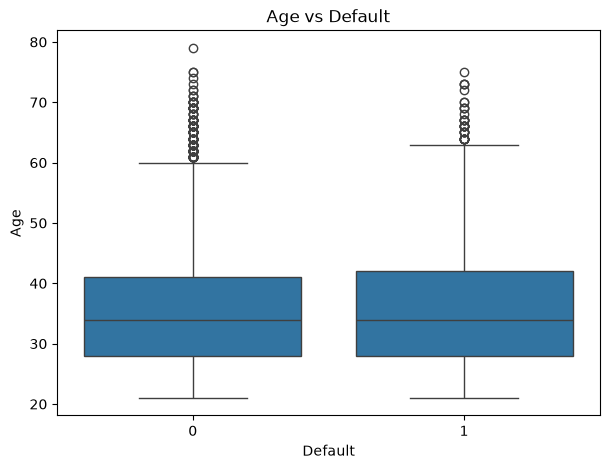

In [27]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=data, x="dpnm", y="AGE")

plt.title("Age vs Default")
plt.xlabel("Default")
plt.ylabel("Age")

plt.show()

In [28]:
data["LIMIT_BAL"].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

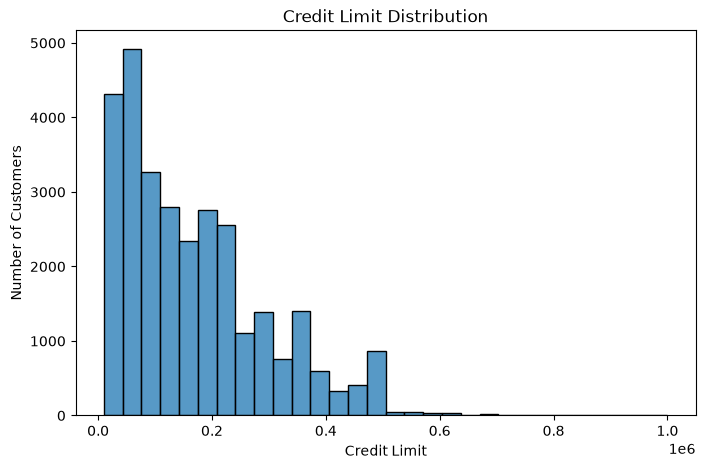

In [29]:
plt.figure(figsize=(8, 5))

sns.histplot(data=data, x="LIMIT_BAL", bins=30)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Number of Customers")

plt.show()

In [30]:
data.groupby("dpnm")["LIMIT_BAL"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
dpnm,,,,,
0,23364,178099.726074,150000.0,10000,1000000
1,6636,130109.656420,90000.0,10000,740000


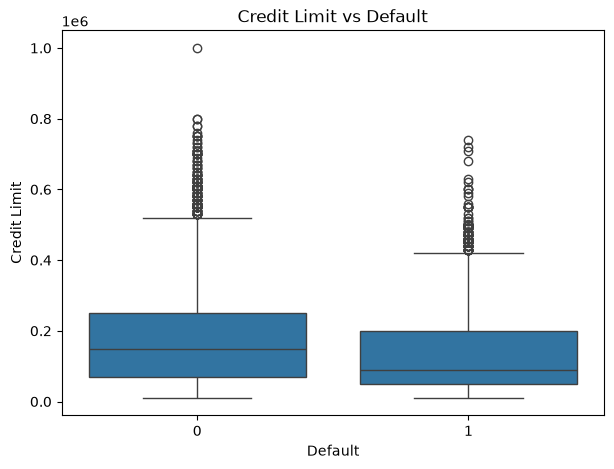

In [31]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=data, x="dpnm", y="LIMIT_BAL")

plt.title("Credit Limit vs Default")
plt.xlabel("Default")
plt.ylabel("Credit Limit")

plt.show()

In [32]:
bill_amt_cols = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

In [33]:
data[bill_amt_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
BILL_AMT1,30000.0,51223.330900,73635.860576,-165580.0,3558.75,22381.5,67091.00,964511.0
BILL_AMT2,30000.0,49179.075167,71173.768783,-69777.0,2984.75,21200.0,64006.25,983931.0
BILL_AMT3,30000.0,47013.154800,69349.387427,-157264.0,2666.25,20088.5,60164.75,1664089.0
BILL_AMT4,30000.0,43262.948967,64332.856134,-170000.0,2326.75,19052.0,54506.00,891586.0
BILL_AMT5,30000.0,40311.400967,60797.155770,-81334.0,1763.00,18104.5,50190.50,927171.0
BILL_AMT6,30000.0,38871.760400,59554.107537,-339603.0,1256.00,17071.0,49198.25,961664.0


In [34]:
data.groupby("dpnm")[bill_amt_cols].agg(
    ["mean", "median"]
)

BILL_AMT1              BILL_AMT2              BILL_AMT3           \
              mean   median          mean   median          mean   median   
dpnm                                                                        
0     51994.227273  23119.5  49717.435670  21660.5  47533.365605  20202.5   
1     48509.162297  20185.0  47283.617842  20300.5  45181.598855  19834.5   

         BILL_AMT4              BILL_AMT5              BILL_AMT6           
              mean   median          mean   median          mean   median  
dpnm                                                                       
0     43611.165254  19000.0  40530.445343  17998.0  39042.268704  16679.0  
1     42036.950573  19119.5  39540.190476  18478.5  38271.435503  18028.5

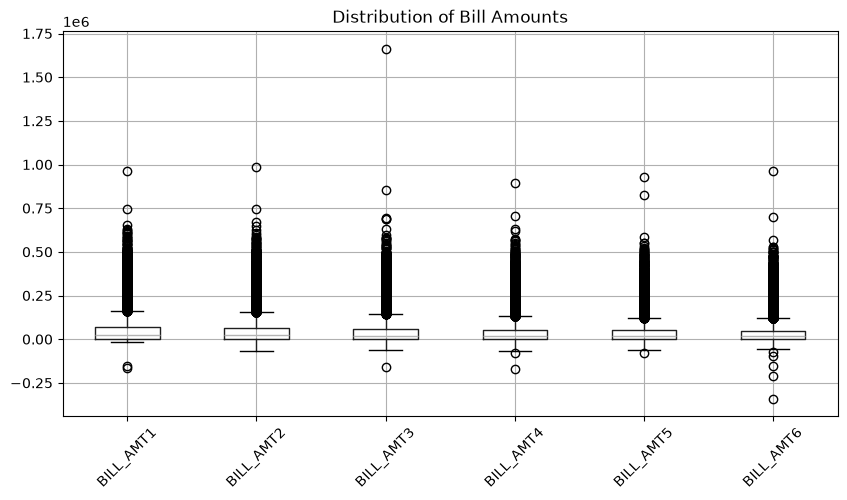

In [35]:
plt.figure(figsize=(10, 5))

data[bill_amt_cols].boxplot()

plt.title("Distribution of Bill Amounts")
plt.xticks(rotation=45)

plt.show()

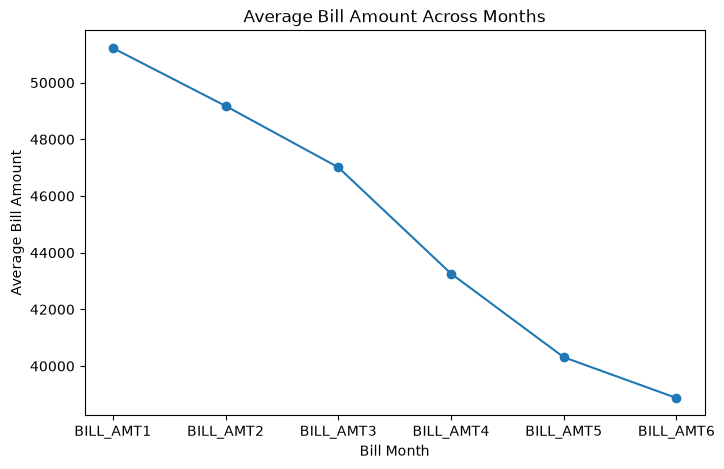

In [36]:
data[bill_amt_cols].mean().plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Average Bill Amount Across Months")
plt.xlabel("Bill Month")
plt.ylabel("Average Bill Amount")

plt.show()

In [37]:
pay_amt_cols = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

In [38]:
data[pay_amt_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PAY_AMT1,30000.0,5663.580500,16563.280354,0.0,1000.00,2100.0,5006.00,873552.0
PAY_AMT2,30000.0,5921.163500,23040.870402,0.0,833.00,2009.0,5000.00,1684259.0
PAY_AMT3,30000.0,5225.681500,17606.961470,0.0,390.00,1800.0,4505.00,896040.0
PAY_AMT4,30000.0,4826.076867,15666.159744,0.0,296.00,1500.0,4013.25,621000.0
PAY_AMT5,30000.0,4799.387633,15278.305679,0.0,252.50,1500.0,4031.50,426529.0
PAY_AMT6,30000.0,5215.502567,17777.465775,0.0,117.75,1500.0,4000.00,528666.0


In [39]:
data.groupby("dpnm")[pay_amt_cols].agg(
    ["mean", "median"]
)

PAY_AMT1             PAY_AMT2             PAY_AMT3          \
             mean  median         mean  median         mean  median   
dpnm                                                                  
0     6307.337357  2459.5  6640.465074  2247.5  5753.496833  2000.0   
1     3397.044153  1636.0  3388.649638  1533.5  3367.351567  1222.0   

         PAY_AMT4             PAY_AMT5             PAY_AMT6          
             mean  median         mean  median         mean  median  
dpnm                                                                 
0     5300.529319  1734.0  5248.220296  1765.0  5719.371769  1706.0  
1     3155.626733  1000.0  3219.139542  1000.0  3441.482068  1000.0

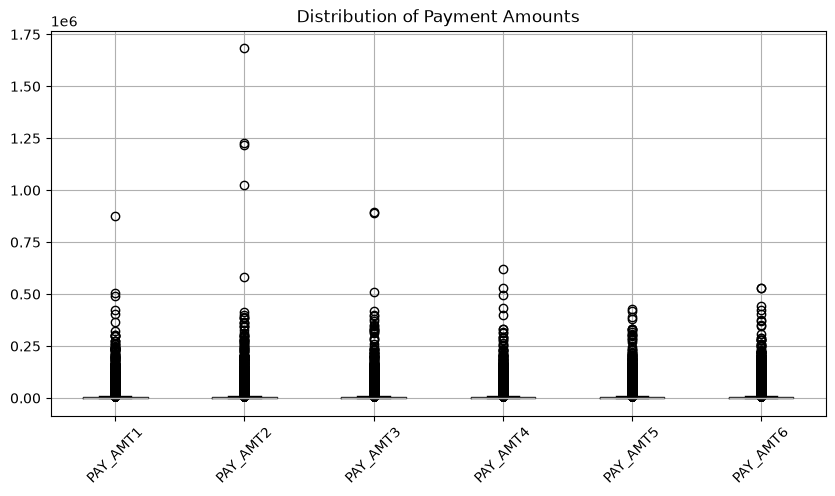

In [40]:
plt.figure(figsize=(10, 5))

data[pay_amt_cols].boxplot()

plt.title("Distribution of Payment Amounts")
plt.xticks(rotation=45)

plt.show()

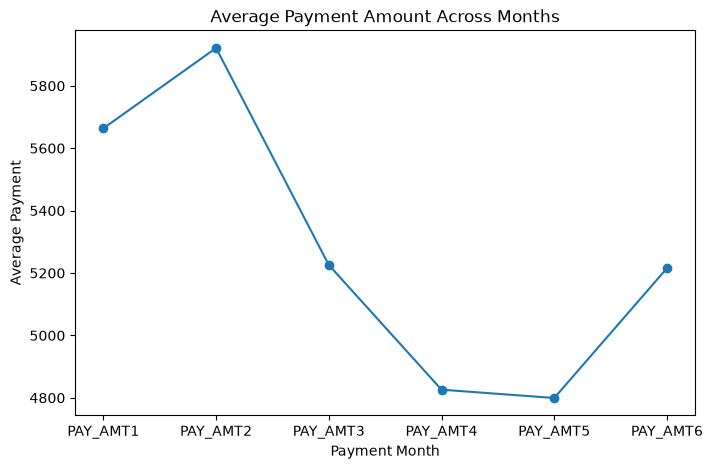

In [41]:
data[pay_amt_cols].mean().plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Average Payment Amount Across Months")
plt.xlabel("Payment Month")
plt.ylabel("Average Payment")

plt.show()

In [42]:
pay_status_cols = [
    "PAY_1",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

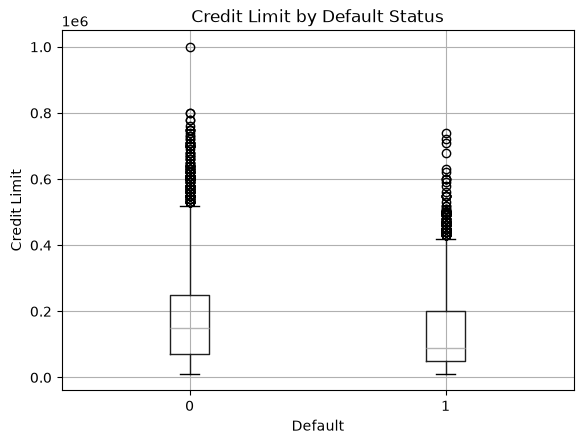

In [43]:
df.boxplot(column="LIMIT_BAL", by="dpnm")

plt.title("Credit Limit by Default Status")
plt.suptitle("")
plt.xlabel("Default")
plt.ylabel("Credit Limit")
plt.show()

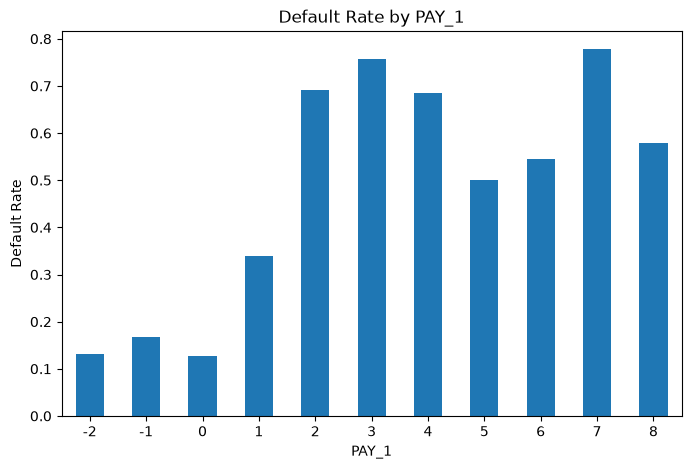

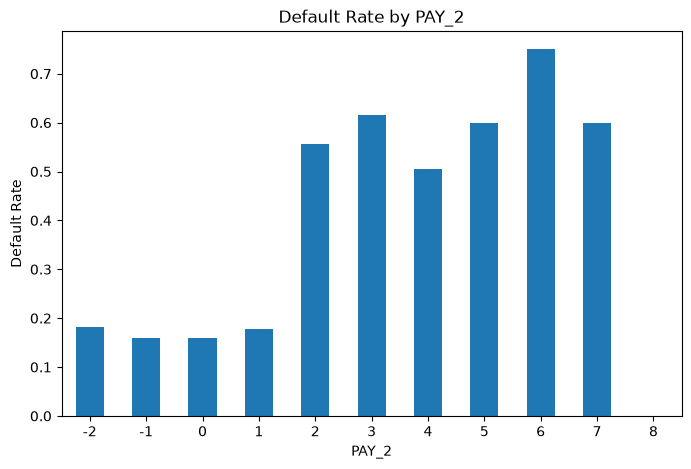

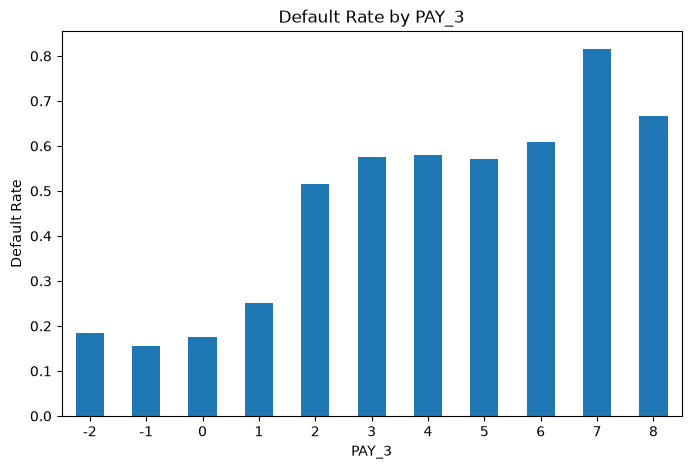

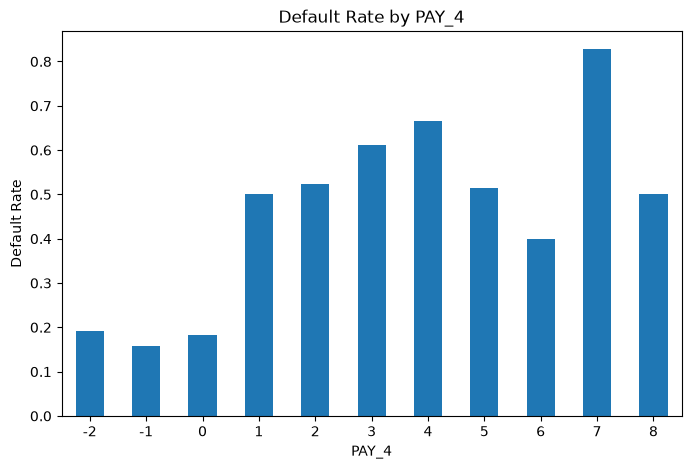

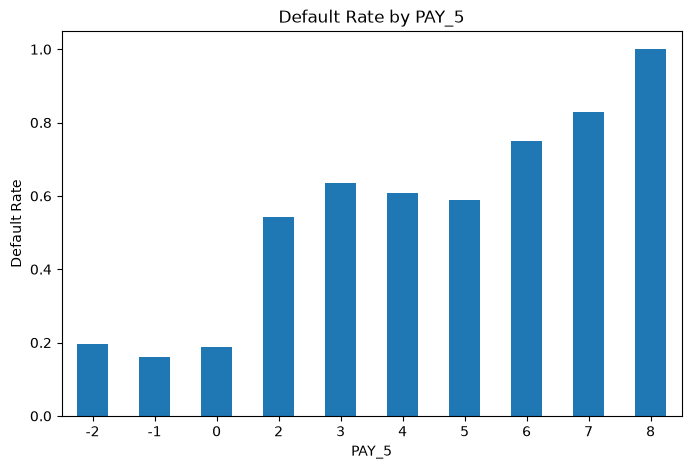

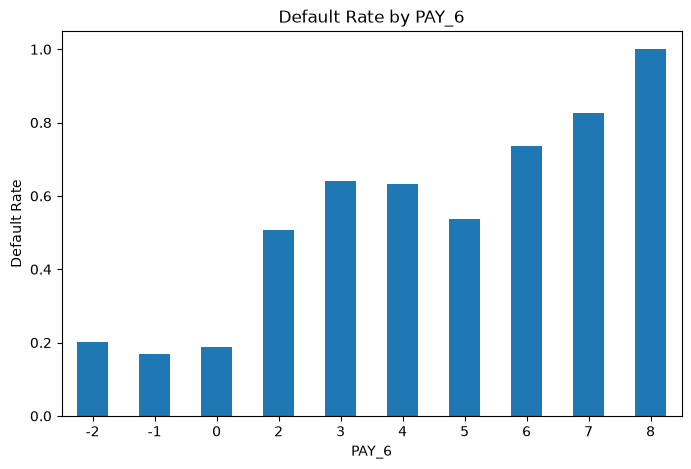

In [44]:
for col in pay_status_cols:
    
    plt.figure(figsize=(8, 5))
    
    default_rate = data.groupby(col)["dpnm"].mean()
    
    default_rate.plot(kind="bar")
    
    plt.title(f"Default Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Default Rate")
    
    plt.xticks(rotation=0)
    plt.show()

In [45]:
categorical_cols = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

In [46]:
for col in categorical_cols:
    
    print(f"\n{col}")
    print(data[col].value_counts().sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64


In [47]:
for col in categorical_cols:
    
    print(f"\n{col}")
    
    print(
        data.groupby(col)["dpnm"]
        .agg(["count", "sum", "mean"])
    )


SEX
     count   sum      mean
SEX                       
1    11888  2873  0.241672
2    18112  3763  0.207763

EDUCATION
           count   sum      mean
EDUCATION                       
0             14     0  0.000000
1          10585  2036  0.192348
2          14030  3330  0.237349
3           4917  1237  0.251576
4            123     7  0.056911
5            280    18  0.064286
6             51     8  0.156863

MARRIAGE
          count   sum      mean
MARRIAGE                       
0            54     5  0.092593
1         13659  3206  0.234717
2         15964  3341  0.209283
3           323    84  0.260062


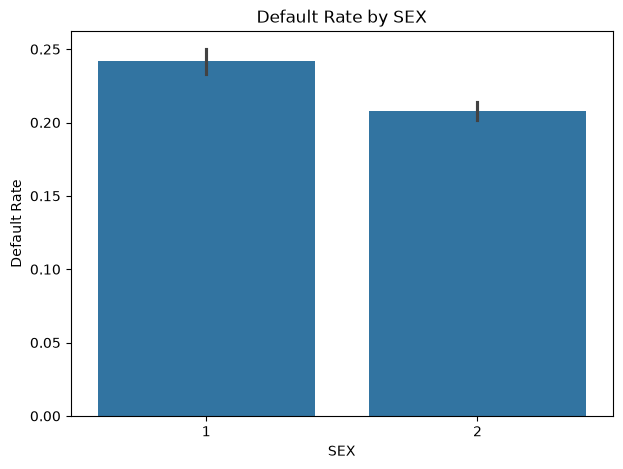

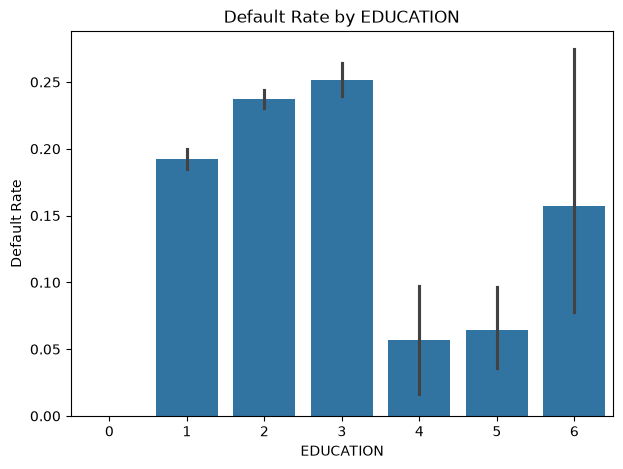

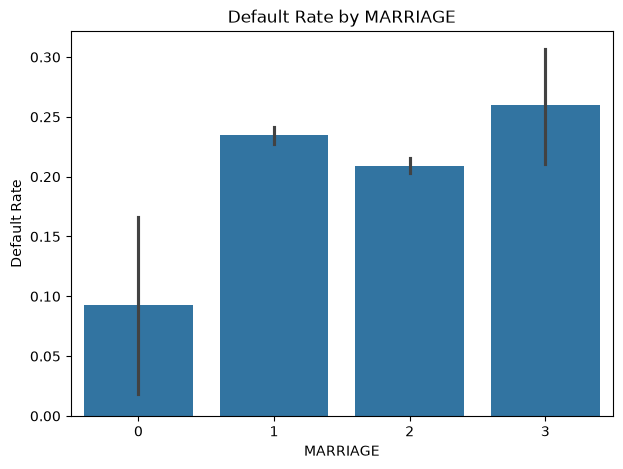

In [48]:
for col in categorical_cols:
    
    plt.figure(figsize=(7, 5))
    
    sns.barplot(
        data=data,
        x=col,
        y="dpnm",
        estimator="mean"
    )
    
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Default Rate")
    
    plt.show()

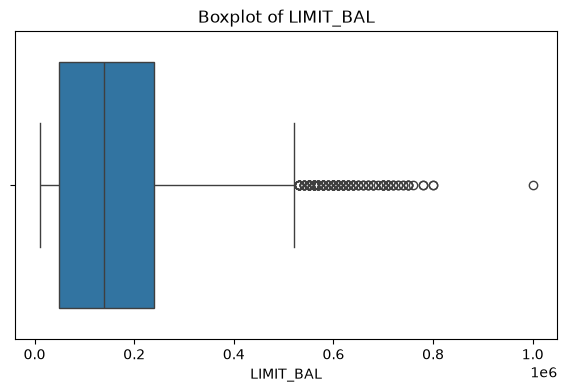

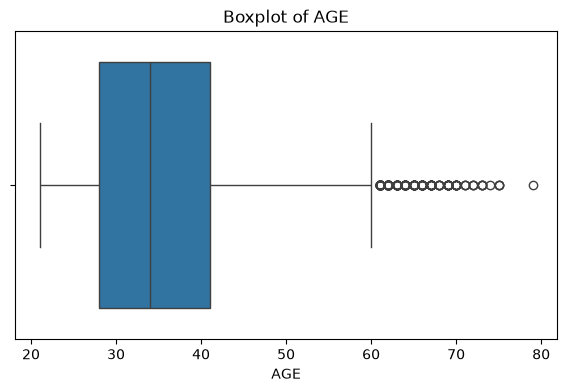

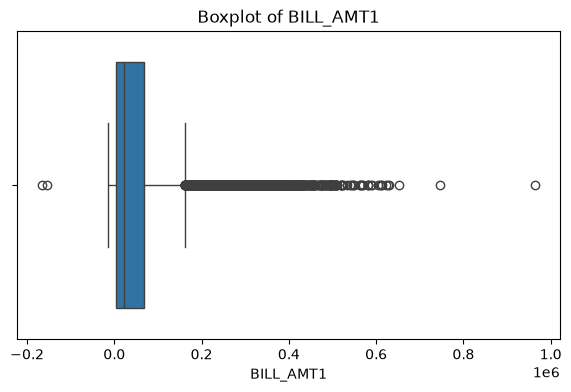

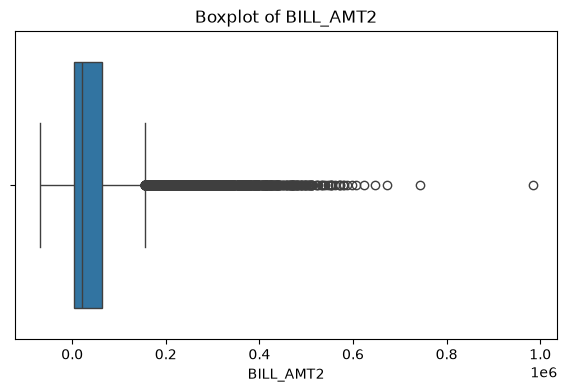

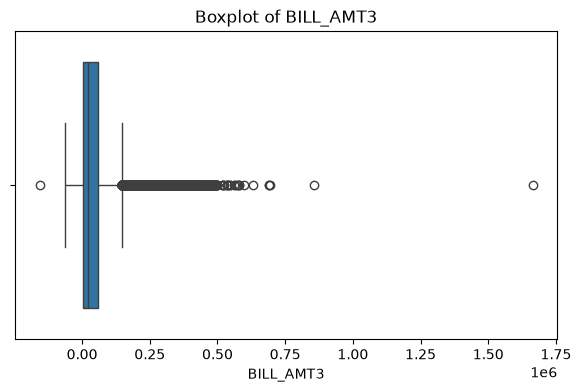

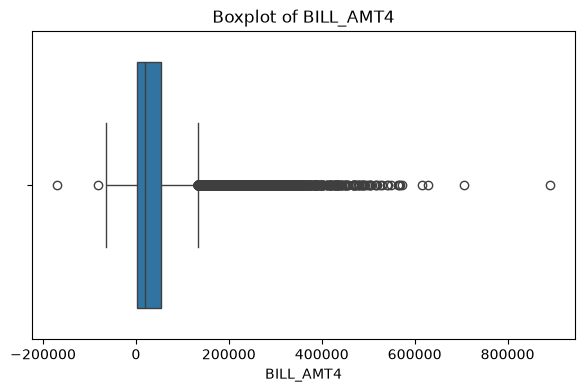

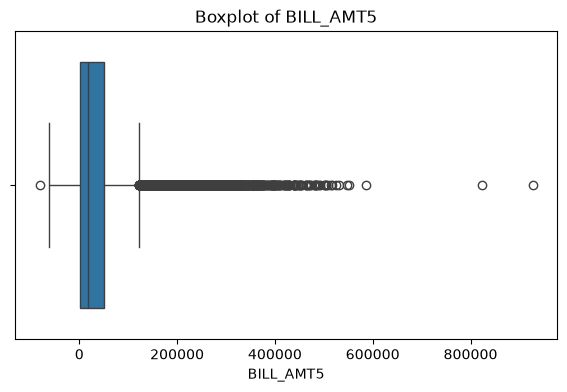

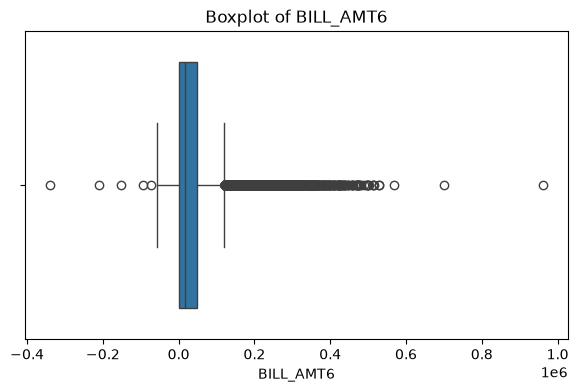

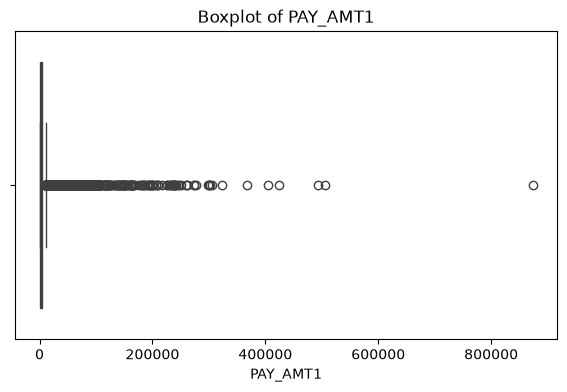

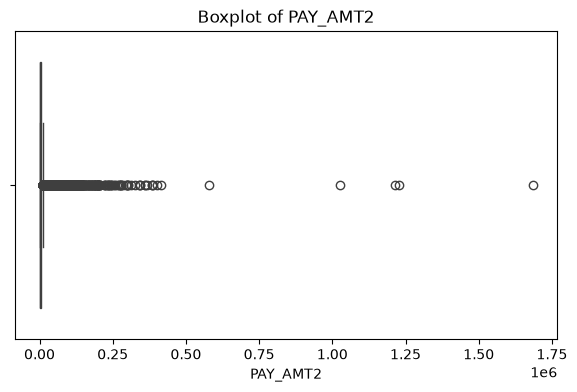

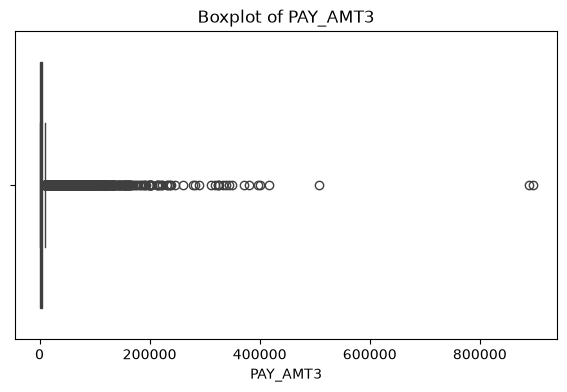

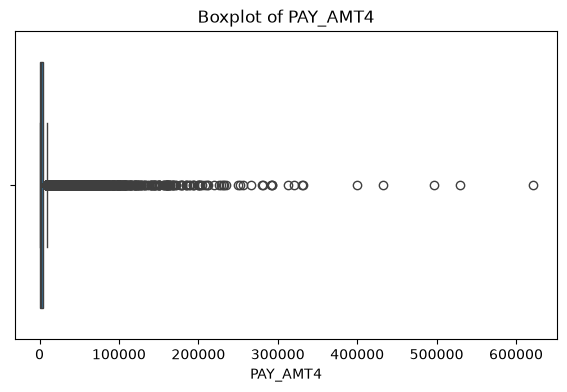

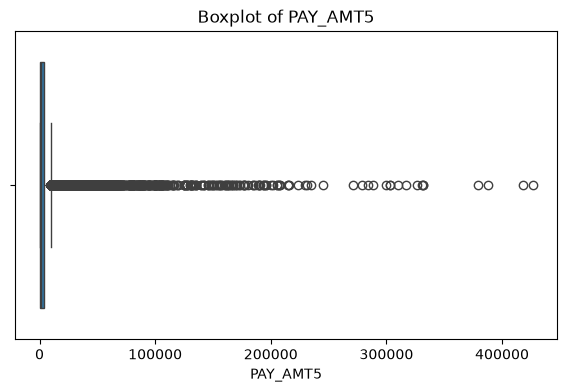

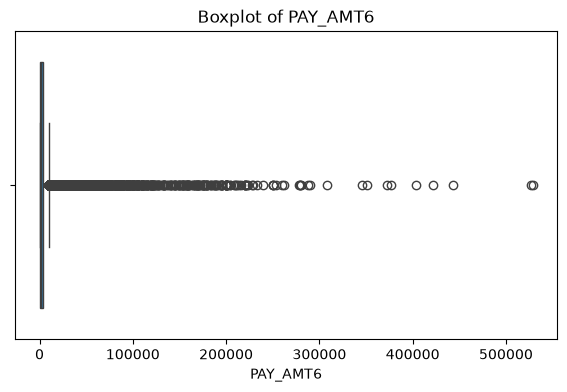

In [49]:
for col in numerical_cols:
    
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(data=data, x=col)
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

In [50]:
# outerliears hongye toh dekhenge 

In [51]:
corr = data.corr(numeric_only=True)

In [52]:
corr["dpnm"].sort_values()

LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
MARRIAGE    -0.024339
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
AGE          0.013890
EDUCATION    0.028006
PAY_6        0.186866
PAY_5        0.204149
PAY_4        0.216614
PAY_3        0.235253
PAY_2        0.263551
PAY_1        0.324794
dpnm         1.000000
Name: dpnm, dtype: float64

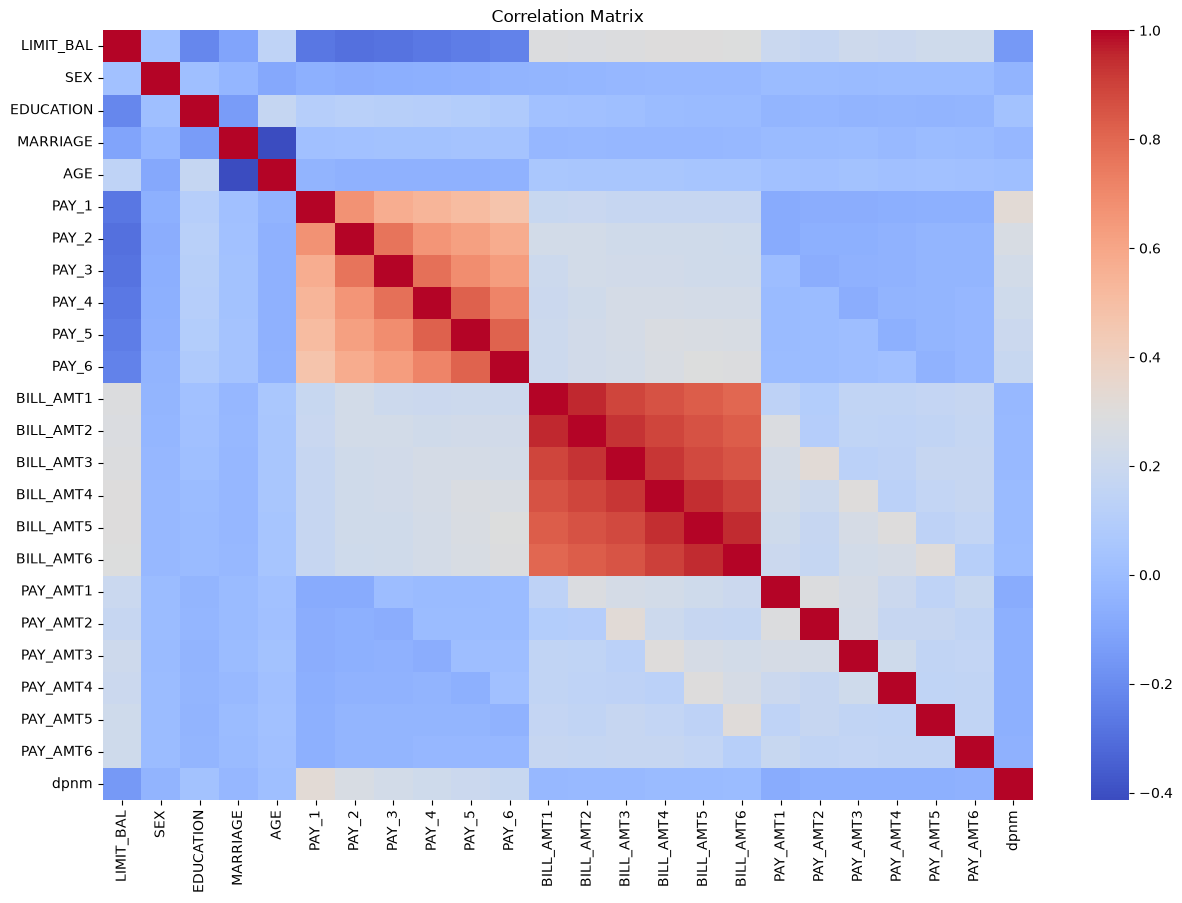

In [53]:
plt.figure(figsize=(15, 10))

sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [54]:
# FEATURE ENGINEERING

In [55]:
data["NUM_DELAYED_MONTHS"] = (
    data[pay_status_cols] > 0
).sum(axis=1)

In [56]:
data["MAX_DELAY"] = data[pay_status_cols].max(axis=1)

In [57]:
data["TOTAL_PAY_AMT"] = data[pay_amt_cols].sum(axis=1)

In [58]:
data["AVG_PAY_AMT"] = data[pay_amt_cols].mean(axis=1)

In [59]:
data["MAX_PAY_AMT"] = data[pay_amt_cols].max(axis=1)

In [60]:
data["ZERO_PAY_MONTHS"] = (
    data[pay_amt_cols] == 0
).sum(axis=1)

In [61]:
data["TOTAL_BILL_AMT"] = data[bill_amt_cols].sum(axis=1)

In [62]:
data["AVG_BILL_AMT"] = data[bill_amt_cols].mean(axis=1)

In [63]:
data["MAX_BILL_AMT"] = data[bill_amt_cols].max(axis=1)

In [64]:
data["BILL_CHANGE_RECENT"] = (
    data["BILL_AMT1"] - data["BILL_AMT6"]
)

In [65]:
data["PAY_CHANGE_RECENT"] = (
    data["PAY_AMT1"] - data["PAY_AMT6"]
)

In [66]:
data["PAY_BILL_RATIO"] = (
    data["TOTAL_PAY_AMT"] /
    (data["TOTAL_BILL_AMT"].abs() + 1)
)

In [67]:
engineered_cols = [
    "NUM_DELAYED_MONTHS",
    "MAX_DELAY",
    "TOTAL_PAY_AMT",
    "AVG_PAY_AMT",
    "MAX_PAY_AMT",
    "ZERO_PAY_MONTHS",
    "TOTAL_BILL_AMT",
    "AVG_BILL_AMT",
    "MAX_BILL_AMT",
    "BILL_CHANGE_RECENT",
    "PAY_CHANGE_RECENT",
    "PAY_BILL_RATIO"
]

In [68]:
data[engineered_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
NUM_DELAYED_MONTHS,30000.0,0.834200,1.554303,0.000000,0.000000,0.000000,1.000000,6.000000e+00
MAX_DELAY,30000.0,0.438733,1.345154,-2.000000,0.000000,0.000000,2.000000,8.000000e+00
TOTAL_PAY_AMT,30000.0,31651.392567,60827.677939,0.000000,6679.750000,14383.000000,33503.500000,3.764066e+06
AVG_PAY_AMT,30000.0,5275.232094,10137.946323,0.000000,1113.291667,2397.166667,5583.916667,6.273443e+05
MAX_PAY_AMT,30000.0,15848.230133,37933.561204,0.000000,2198.000000,5000.000000,12100.000000,1.684259e+06
ZERO_PAY_MONTHS,30000.0,1.229900,1.718588,0.000000,0.000000,0.000000,2.000000,6.000000e+00
TOTAL_BILL_AMT,30000.0,269861.671200,379564.331162,-336259.000000,28688.000000,126311.000000,342626.500000,5.263883e+06
AVG_BILL_AMT,30000.0,44976.945200,63260.721860,-56043.166667,4781.333333,21051.833333,57104.416667,8.773138e+05
MAX_BILL_AMT,30000.0,60572.436867,78404.814025,-6029.000000,10060.000000,31208.500000,79599.000000,1.664089e+06
BILL_CHANGE_RECENT,30000.0,12351.570500,43922.421534,-428791.000000,-2963.000000,923.000000,19793.750000,7.083230e+05


In [69]:
data[engineered_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
NUM_DELAYED_MONTHS,30000.0,0.834200,1.554303,0.000000,0.000000,0.000000,1.000000,6.000000e+00
MAX_DELAY,30000.0,0.438733,1.345154,-2.000000,0.000000,0.000000,2.000000,8.000000e+00
TOTAL_PAY_AMT,30000.0,31651.392567,60827.677939,0.000000,6679.750000,14383.000000,33503.500000,3.764066e+06
AVG_PAY_AMT,30000.0,5275.232094,10137.946323,0.000000,1113.291667,2397.166667,5583.916667,6.273443e+05
MAX_PAY_AMT,30000.0,15848.230133,37933.561204,0.000000,2198.000000,5000.000000,12100.000000,1.684259e+06
ZERO_PAY_MONTHS,30000.0,1.229900,1.718588,0.000000,0.000000,0.000000,2.000000,6.000000e+00
TOTAL_BILL_AMT,30000.0,269861.671200,379564.331162,-336259.000000,28688.000000,126311.000000,342626.500000,5.263883e+06
AVG_BILL_AMT,30000.0,44976.945200,63260.721860,-56043.166667,4781.333333,21051.833333,57104.416667,8.773138e+05
MAX_BILL_AMT,30000.0,60572.436867,78404.814025,-6029.000000,10060.000000,31208.500000,79599.000000,1.664089e+06
BILL_CHANGE_RECENT,30000.0,12351.570500,43922.421534,-428791.000000,-2963.000000,923.000000,19793.750000,7.083230e+05


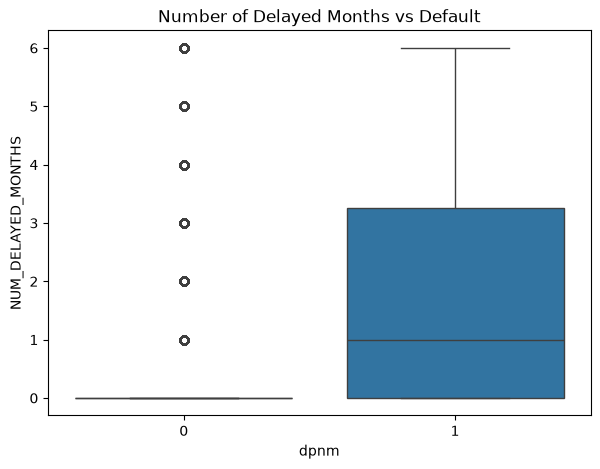

In [70]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data,
    x="dpnm",
    y="NUM_DELAYED_MONTHS"
)

plt.title("Number of Delayed Months vs Default")
plt.show()

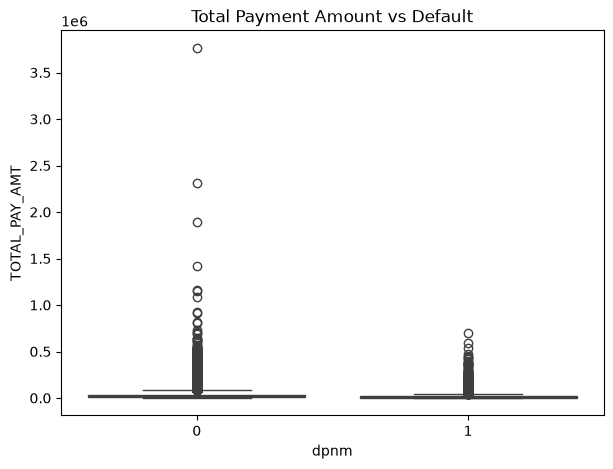

In [71]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=data,
    x="dpnm",
    y="TOTAL_PAY_AMT"
)

plt.title("Total Payment Amount vs Default")
plt.show()

In [72]:
data.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'NUM_DELAYED_MONTHS', 'MAX_DELAY', 'TOTAL_PAY_AMT', 'AVG_PAY_AMT',
       'MAX_PAY_AMT', 'ZERO_PAY_MONTHS', 'TOTAL_BILL_AMT', 'AVG_BILL_AMT',
       'MAX_BILL_AMT', 'BILL_CHANGE_RECENT', 'PAY_CHANGE_RECENT',
       'PAY_BILL_RATIO'],
      dtype='str')

In [73]:
data.columns.tolist()

['LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'dpnm',
 'NUM_DELAYED_MONTHS',
 'MAX_DELAY',
 'TOTAL_PAY_AMT',
 'AVG_PAY_AMT',
 'MAX_PAY_AMT',
 'ZERO_PAY_MONTHS',
 'TOTAL_BILL_AMT',
 'AVG_BILL_AMT',
 'MAX_BILL_AMT',
 'BILL_CHANGE_RECENT',
 'PAY_CHANGE_RECENT',
 'PAY_BILL_RATIO']

In [74]:
data.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'NUM_DELAYED_MONTHS', 'MAX_DELAY', 'TOTAL_PAY_AMT', 'AVG_PAY_AMT',
       'MAX_PAY_AMT', 'ZERO_PAY_MONTHS', 'TOTAL_BILL_AMT', 'AVG_BILL_AMT',
       'MAX_BILL_AMT', 'BILL_CHANGE_RECENT', 'PAY_CHANGE_RECENT',
       'PAY_BILL_RATIO'],
      dtype='str')

In [75]:
data["LIMIT_BAL"].nunique()

81

In [76]:
# MODEL TESTING AND TRAINING 

In [77]:
X = data.drop(columns = ["dpnm"])

In [78]:
data.shape

(30000, 36)

In [79]:
Y = data["dpnm"]

In [80]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,
    test_size = 0.2,random_state = 42,stratify = Y
)

In [81]:
X_train.shape

(24000, 35)

In [82]:
X_test.shape

(6000, 35)

In [83]:
Y_train.shape

(24000,)

In [84]:
Y_test.shape

(6000,)

In [85]:
Y_train.value_counts(normalize = True)

dpnm
0    0.778792
1    0.221208
Name: proportion, dtype: float64

In [86]:
Y_test.value_counts(normalize = True)

dpnm
0    0.778833
1    0.221167
Name: proportion, dtype: float64

In [87]:
numerical_features = X.select_dtypes(include = ["int64","float64"]).columns

In [88]:
categorical_features = X.select_dtypes(include = ["object"]).columns

In [89]:
numerical_pipeline = Pipeline(
    [
        ("imputer",SimpleImputer(strategy = "median")),
        ("scalar" ,StandardScaler())
    ]
)

In [90]:
categorical_pipeline = Pipeline(
    [
        ("imputer",SimpleImputer(strategy = "most_frequent")),
        ("encoder",OneHotEncoder(handle_unknown = "ignore"))
            
    ]
)

In [91]:
preprocessor = ColumnTransformer( transformers =
    [
        ("num",numerical_pipeline,numerical_features),("cat",categorical_pipeline,categorical_features)
    ]
)

In [92]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [93]:
# MODELS APPLYING AND EVALUATION

In [94]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [95]:
logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [96]:
logistic_model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['LIMIT_BAL','SEX','EDUCATION',...,'BILL_CHANGE_RECENT', 'PAY_CHANGE_RECENT','PAY_BILL_RATIO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [97]:
Y_pred = logistic_model.predict(X_test)
Y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(6000,))

In [98]:
Y_prob = logistic_model.predict_proba(X_test)[:, 1]
Y_prob

array([0.1358633 , 0.17042868, 0.14278313, ..., 0.11609962, 0.14866261,
       0.09967975], shape=(6000,))

In [99]:
print("Accuracy :", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall   :", recall_score(Y_test, Y_pred))
print("F1 Score :", f1_score(Y_test, Y_pred))
print("ROC-AUC  :", roc_auc_score(Y_test, Y_prob))

Accuracy : 0.807
Precision: 0.6405990016638935
Recall   : 0.2901281085154484
F1 Score : 0.3993775933609959
ROC-AUC  : 0.742821038494802


In [100]:
(classification_report(Y_test, Y_pred))

'              precision    recall  f1-score   support\n\n           0       0.83      0.95      0.89      4673\n           1       0.64      0.29      0.40      1327\n\n    accuracy                           0.81      6000\n   macro avg       0.73      0.62      0.64      6000\nweighted avg       0.78      0.81      0.78      6000\n'

In [101]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.64      0.29      0.40      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.62      0.64      6000
weighted avg       0.78      0.81      0.78      6000



In [102]:
cm = confusion_matrix(Y_test, Y_pred)
cm


array([[4457,  216],
       [ 942,  385]])

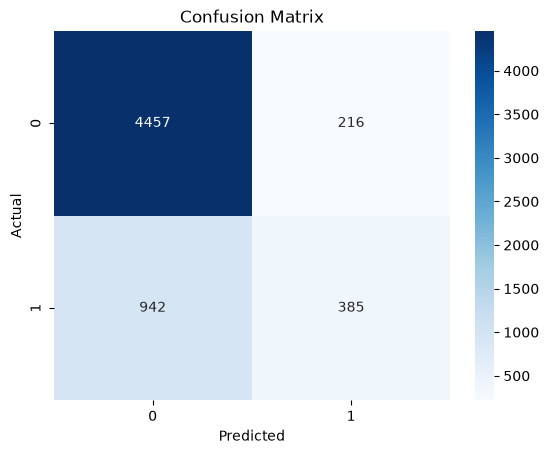

In [103]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [104]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

dt_model.fit(X_train, Y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [105]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [106]:
gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

gb_model.fit(X_train, Y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

In [107]:
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [108]:
xgb_model.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](35,)","['LIMIT_BAL','SEX','EDUCATION',...,'BILL_CHANGE_RECENT', 'PAY_CHANGE_RECENT','PAY_BILL_RATIO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,35
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [109]:
def evaluate_model(model, X_test, Y_test):
    
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Accuracy": accuracy_score(Y_test, pred),
        "Precision": precision_score(Y_test, pred),
        "Recall": recall_score(Y_test, pred),
        "F1": f1_score(Y_test, pred),
        "ROC-AUC": roc_auc_score(Y_test, prob)
    }

In [110]:
evaluate_model(logistic_model, X_test, Y_test)

{'Accuracy': 0.807,
 'Precision': 0.6405990016638935,
 'Recall': 0.2901281085154484,
 'F1': 0.3993775933609959,
 'ROC-AUC': 0.742821038494802}

In [111]:
evaluate_model(dt_model, X_test, Y_test)

{'Accuracy': 0.7231666666666666,
 'Precision': 0.37985611510791367,
 'Recall': 0.39788997739261495,
 'F1': 0.38866396761133604,
 'ROC-AUC': 0.6078082318360811}

In [112]:
evaluate_model(rf_model, X_test, Y_test)

{'Accuracy': 0.813,
 'Precision': 0.6329442282749675,
 'Recall': 0.3677467972871138,
 'F1': 0.4652049571020019,
 'ROC-AUC': 0.7622413128312834}

In [113]:
evaluate_model(gb_model, X_test, Y_test)

{'Accuracy': 0.8208333333333333,
 'Precision': 0.6707317073170732,
 'Recall': 0.3730218538055765,
 'F1': 0.4794188861985472,
 'ROC-AUC': 0.77759882123588}

In [114]:
evaluate_model(xgb_model, X_test, Y_test)

{'Accuracy': 0.8193333333333334,
 'Precision': 0.6675862068965517,
 'Recall': 0.36473247927656366,
 'F1': 0.47173489278752434,
 'ROC-AUC': 0.7777583904457794}

In [115]:
results = pd.DataFrame({
    "Logistic Regression": evaluate_model(
        logistic_model, X_test, Y_test
    ),
    
    "Decision Tree": evaluate_model(
        dt_model, X_test, Y_test
    ),
    
    "Random Forest": evaluate_model(
        rf_model, X_test, Y_test
    ),
    
    "Gradient Boosting": evaluate_model(
        gb_model, X_test, Y_test
    ),
    
    "XGBoost": evaluate_model(
        xgb_model, X_test, Y_test
    )
}).T

In [116]:
results

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.807000,0.640599,0.290128,0.399378,0.742821
Decision Tree,0.723167,0.379856,0.397890,0.388664,0.607808
Random Forest,0.813000,0.632944,0.367747,0.465205,0.762241
Gradient Boosting,0.820833,0.670732,0.373022,0.479419,0.777599
XGBoost,0.819333,0.667586,0.364732,0.471735,0.777758


In [117]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [118]:
cv_results = []

for name, model in {
    "Logistic Regression": logistic_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}.items():

    scores = cross_val_score(
        model,
        X_train,
        Y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1    )

    cv_results.append({
        "Model": name,
        "Mean ROC-AUC": scores.mean(),
        "Std ROC-AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="Mean ROC-AUC",
    ascending=False
)

,Model,Mean ROC-AUC,Std ROC-AUC
3,Gradient Boosting,0.783175,0.006485
4,XGBoost,0.781781,0.006787
2,Random Forest,0.766615,0.002041
0,Logistic Regression,0.758949,0.006260
1,Decision Tree,0.614231,0.004762


In [119]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "subsample": [0.8, 0.9, 1.0]
}

gb_random = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

gb_random.fit(X_train, Y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` c

In [120]:
print("Best Parameters:")
print(gb_random.best_params_)

print("\nBest CV ROC-AUC:")
print(gb_random.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 250, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 4, 'learning_rate': 0.03}

Best CV ROC-AUC:
0.7856556823414172


In [121]:
best_gb = gb_random.best_estimator_

In [122]:
best_gb

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.03
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",250
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (

In [123]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_param_grid = {
    "n_estimators": [100, 150, 200, 250, 300],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 2, 5, 10]
}

xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_random.fit(X_train, Y_train)

Fitting 5 folds for each of 15 candidates, totalling 75 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can b

In [124]:
print("Best Parameters:")
print(xgb_random.best_params_)

print("\nBest CV ROC-AUC:")
print(xgb_random.best_score_)

Best Parameters:
{'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.7}

Best CV ROC-AUC:
0.7866776922790767


In [125]:
best_xgb = xgb_random.best_estimator_

In [126]:
best_xgb

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [127]:
tuned_results = pd.DataFrame({
    "Model": [
        "Tuned Gradient Boosting",
        "Tuned XGBoost"
    ],
    "CV ROC-AUC": [
        gb_random.best_score_,
        xgb_random.best_score_
    ]
})

tuned_results.sort_values(
    by="CV ROC-AUC",
    ascending=False
)

,Model,CV ROC-AUC
1,Tuned XGBoost,0.786678
0,Tuned Gradient Boosting,0.785656


In [128]:
best_xgb = xgb_random.best_estimator_

In [129]:
best_xgb

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.7
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [130]:
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [131]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(6000,))

In [132]:
y_prob

array([0.14490245, 0.11451379, 0.14309815, ..., 0.0693721 , 0.13463734,
       0.08485647], shape=(6000,), dtype=float32)

In [133]:
print("Accuracy :", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall   :", recall_score(Y_test, y_pred))
print("F1 Score :", f1_score(Y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(Y_test, y_prob))

Accuracy : 0.8216666666666667
Precision: 0.6792189679218968
Recall   : 0.36699321778447624
F1 Score : 0.4765166340508806
ROC-AUC  : 0.7796708020275853


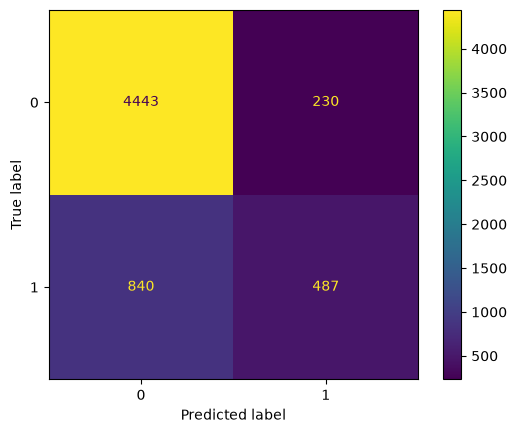

In [134]:
cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [135]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.68      0.37      0.48      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.68      6000
weighted avg       0.81      0.82      0.80      6000



In [136]:
y_train_prob = cross_val_predict(
    best_xgb,
    X_train,
    Y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [137]:
y_train_prob


array([0.7681546 , 0.28476933, 0.40882412, ..., 0.10499167, 0.23399773,
       0.19889534], shape=(24000,), dtype=float32)

In [138]:
thresholds = np.arange(0.30, 0.71, 0.01)

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_train_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(Y_train, y_pred_threshold),
        "Recall": recall_score(Y_train, y_pred_threshold),
        "F1": f1_score(Y_train, y_pred_threshold)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Precision,Recall,F1
0,0.30,0.539212,0.551705,0.545387
1,0.31,0.545713,0.543040,0.544373
2,0.32,0.553279,0.533999,0.543468
3,0.33,0.562955,0.523827,0.542687
4,0.34,0.573969,0.516670,0.543814
5,0.35,0.583279,0.503296,0.540344
6,0.36,0.593864,0.492183,0.538263
7,0.37,0.601983,0.480316,0.534311
8,0.38,0.609990,0.466943,0.528966
9,0.39,0.619621,0.455641,0.525128


In [139]:
best_threshold_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best Threshold:", best_threshold)
print("Best F1:", best_threshold_row["F1"])
print("Precision:", best_threshold_row["Precision"])
print("Recall:", best_threshold_row["Recall"])

Best Threshold: 0.3
Best F1: 0.5453868354901779
Precision: 0.5392120765832106
Recall: 0.551704652476926


In [140]:
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

In [141]:
y_test_pred_threshold = (
    y_test_prob >= best_threshold
).astype(int)

In [142]:
print("Threshold:", best_threshold)
print("Accuracy :", accuracy_score(Y_test, y_test_pred_threshold))
print("Precision:", precision_score(Y_test, y_test_pred_threshold))
print("Recall   :", recall_score(Y_test, y_test_pred_threshold))
print("F1 Score :", f1_score(Y_test, y_test_pred_threshold))
print("ROC-AUC  :", roc_auc_score(Y_test, y_test_prob))

Threshold: 0.3
Accuracy : 0.7958333333333333
Precision: 0.5377218934911243
Recall   : 0.5478522984174831
F1 Score : 0.5427398282941396
ROC-AUC  : 0.7796708020275853


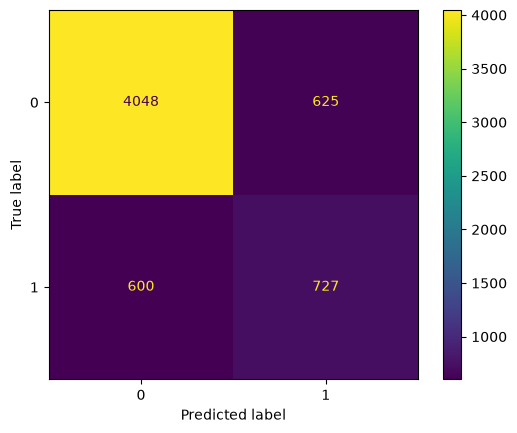

In [143]:
cm = confusion_matrix(
    Y_test,
    y_test_pred_threshold
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.show()

In [144]:
print(X_train.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'NUM_DELAYED_MONTHS', 'MAX_DELAY', 'TOTAL_PAY_AMT', 'AVG_PAY_AMT', 'MAX_PAY_AMT', 'ZERO_PAY_MONTHS', 'TOTAL_BILL_AMT', 'AVG_BILL_AMT', 'MAX_BILL_AMT', 'BILL_CHANGE_RECENT', 'PAY_CHANGE_RECENT', 'PAY_BILL_RATIO']


In [145]:
new_customer = pd.DataFrame({
    "LIMIT_BAL": [50000],
    "SEX": [2],
    "EDUCATION": [2],
    "MARRIAGE": [2],
    "AGE": [30],

    "PAY_1": [0],
    "PAY_2": [0],
    "PAY_3": [0],
    "PAY_4": [0],
    "PAY_5": [0],
    "PAY_6": [0],

    "BILL_AMT1": [50000],
    "BILL_AMT2": [48000],
    "BILL_AMT3": [45000],
    "BILL_AMT4": [43000],
    "BILL_AMT5": [40000],
    "BILL_AMT6": [38000],

    "PAY_AMT1": [5000],
    "PAY_AMT2": [5000],
    "PAY_AMT3": [5000],
    "PAY_AMT4": [5000],
    "PAY_AMT5": [5000],
    "PAY_AMT6": [5000]
})

In [146]:
pay_status_cols = [
    "PAY_1", "PAY_2", "PAY_3",
    "PAY_4", "PAY_5", "PAY_6"
]

pay_amt_cols = [
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3",
    "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

bill_amt_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

# Number of months with delayed payment
new_customer["NUM_DELAYED_MONTHS"] = (
    new_customer[pay_status_cols] > 0
).sum(axis=1)

# Maximum payment delay
new_customer["MAX_DELAY"] = (
    new_customer[pay_status_cols].max(axis=1)
)

# Total payment amount
new_customer["TOTAL_PAY_AMT"] = (
    new_customer[pay_amt_cols].sum(axis=1)
)

# Average payment amount
new_customer["AVG_PAY_AMT"] = (
    new_customer[pay_amt_cols].mean(axis=1)
)

# Maximum payment amount
new_customer["MAX_PAY_AMT"] = (
    new_customer[pay_amt_cols].max(axis=1)
)

# Number of months with zero payment
new_customer["ZERO_PAY_MONTHS"] = (
    new_customer[pay_amt_cols] == 0
).sum(axis=1)

# Total bill amount
new_customer["TOTAL_BILL_AMT"] = (
    new_customer[bill_amt_cols].sum(axis=1)
)

# Average bill amount
new_customer["AVG_BILL_AMT"] = (
    new_customer[bill_amt_cols].mean(axis=1)
)

# Maximum bill amount
new_customer["MAX_BILL_AMT"] = (
    new_customer[bill_amt_cols].max(axis=1)
)

# Recent bill change
new_customer["BILL_CHANGE_RECENT"] = (
    new_customer["BILL_AMT1"] -
    new_customer["BILL_AMT2"]
)

# Recent payment change
new_customer["PAY_CHANGE_RECENT"] = (
    new_customer["PAY_AMT1"] -
    new_customer["PAY_AMT2"]
)

# Payment-to-bill ratio
new_customer["PAY_BILL_RATIO"] = (
    new_customer["TOTAL_PAY_AMT"] /
    (new_customer["TOTAL_BILL_AMT"].abs() + 1)
)

In [147]:
new_customer = new_customer[X_train.columns]

In [148]:
print(new_customer.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'NUM_DELAYED_MONTHS', 'MAX_DELAY', 'TOTAL_PAY_AMT', 'AVG_PAY_AMT', 'MAX_PAY_AMT', 'ZERO_PAY_MONTHS', 'TOTAL_BILL_AMT', 'AVG_BILL_AMT', 'MAX_BILL_AMT', 'BILL_CHANGE_RECENT', 'PAY_CHANGE_RECENT', 'PAY_BILL_RATIO']


In [149]:
probability = best_xgb.predict_proba(
    new_customer
)[0, 1]

print(f"Default Probability: {probability:.2%}")

Default Probability: 8.73%


In [150]:
best_threshold

np.float64(0.3)

In [151]:
prediction = int(probability >= best_threshold)

if prediction == 1:
    print("Prediction: Likely to Default")
else:
    print("Prediction: Unlikely to Default")

Prediction: Unlikely to Default


In [152]:
joblib.dump(best_xgb, "xgboost_model.pkl")

['xgboost_model.pkl']

In [153]:
joblib.dump(best_threshold, "threshold.pkl")

['threshold.pkl']

In [154]:
loaded_model = joblib.load("xgboost_model.pkl")
loaded_threshold = joblib.load("threshold.pkl")

print("Model loaded successfully!")
print("Threshold:", loaded_threshold)

Model loaded successfully!
Threshold: 0.3


In [156]:
probability = loaded_model.predict_proba(new_customer)[0, 1]

prediction = int(probability >= loaded_threshold)

print(f"Default Probability: {probability:.2%}")

if prediction == 1:
    print("Prediction: Likely to Default")
else:
    print("Prediction: Unlikely to Default")

Default Probability: 8.73%
Prediction: Unlikely to Default


In [157]:
print(type(best_xgb))

<class 'xgboost.sklearn.XGBClassifier'>


In [162]:
model = joblib.load("xgboost_model.pkl")
threshold = joblib.load("threshold.pkl")